In [170]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [171]:
# Scikit-learn imports
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [172]:
def sigmoid(x):
    return 1./(1.+np.exp(-x))

class LogisticRegressionGD:

    def __init__(self,lr=0.1,n_iter=10,random_state=1):
        self.lr = lr
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self,X,y):
        # assess X and y shapes
        assert(X.shape[0]==y.shape[0])
        # setup random state
        rgen = np.random.RandomState(seed=self.random_state)
        self.w_ = rgen.normal(loc=0.,scale=0.01,size=X.shape[1])
        self.b_ = 0.
        self.losses = []
        for i in range(self.n_iter):
            z = np.dot(X,self.w_)+self.b_
            h = sigmoid(z)
            errors = y-h
            
            self.w_ += self.lr*2.* X.T.dot(errors)/X.shape[0]
            self.b_ += self.lr*2.*errors.mean()
            loss = -y.dot(np.log(h))-(1.-y).dot(np.log(1-h))
            loss = loss / X.shape[0]
            self.losses.append(loss)
            
            
            #print(f"Iter:{i} Weight:{self.w_} Bias: {self.b_} Cost: {loss}")
            # self.errors.append(cost)

    def net_input(self,X):
        return np.dot(X,self.w_)+self.b_
    
    def predict(self,X):
        z = np.dot(X,self.w_)+self.b_
        h = sigmoid(z)
        return np.where(h>=0.5,1,0)

In [173]:
def load_data(datafile='data/iris.csv'):
    try:
        df = pd.read_csv(datafile)
    except:
        print("Error reading data file")
        return None
    y = df.iloc[:,4].values
    y = np.where(y=='Setosa',0,1)
    X = df.iloc[:,[0,2]].values
    return X,y


In [174]:
def plot_data(X):
    plt.scatter(X[:50,0], X[:50,1],
            color='red', marker='o', label='Setosa')
    plt.scatter(X[50:100,0],X[50:100,1],
                color='blue',marker='s',label='Versicolor')
    plt.xlabel('Sepal length [cm]')
    plt.ylabel('Petal length [cm]')
    plt.legend(loc='upper left')
    plt.show()

In [175]:
X,y = load_data()

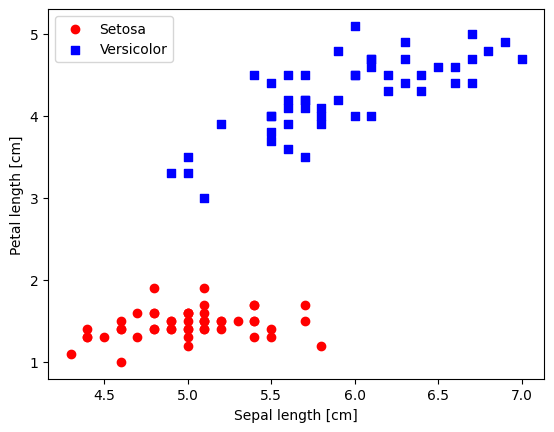

In [176]:
plot_data(X)

In [177]:
model = LogisticRegressionGD(lr=0.1,n_iter=1000,random_state=1)
model.fit(X,y)

In [178]:
from matplotlib.colors import ListedColormap
def plot_decision_regions(X,y,classifier,test_idx=None,resolution=0.02):
    markers = ('o','s','^','v','<')
    colors = ('red','blue','lightgreen','gray','cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:,0].min()-1, X[:,0].max()+1
    x2_min, x2_max = X[:,1].min()-1, X[:,1].max()+1

    xx1, xx2 = np.meshgrid(np.arange(x1_min,x1_max,resolution),
                           np.arange(x2_min,x2_max,resolution))
    
    lab = classifier.predict(np.array([xx1.ravel(),xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1,xx2,lab,alpha=0.3,cmap=cmap)
    plt.xlim(xx1.min(),xx1.max())
    plt.ylim(xx2.min(),xx2.max())

    for idx,cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y==cl,0],
                    y=X[y==cl,1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    # highlight test samples
    if test_idx:
        X_test, y_test = X[test_idx,:], y[test_idx]
        plt.scatter(X_test[:,0],
                    X_test[:,1],
                    c='',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100,
                    label='test set')


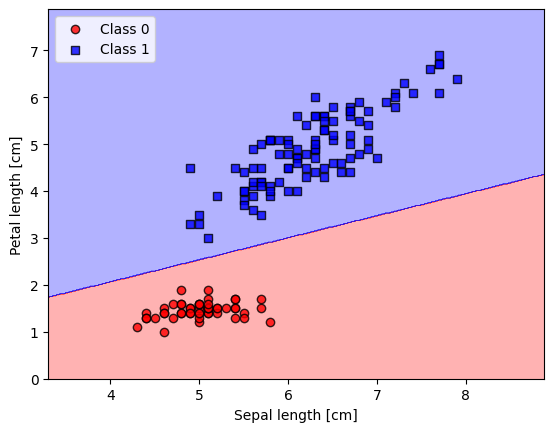

In [179]:
plot_decision_regions(X,y,model)
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.show()

In [180]:
X_std = np.copy(X)
X_std[:,0] = (X[:,0]-X[:,0].mean())/X[:,0].std()
X_std[:,1] = (X[:,1]-X[:,1].mean())/X[:,1].std()


Text(0.5, 0, 'Sepal length [cm] (standardized)')

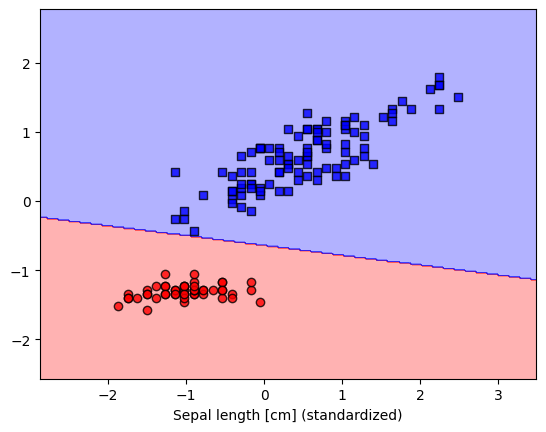

In [181]:
model.fit(X_std,y)
plot_decision_regions(X_std,y,model)
plt.xlabel('Sepal length [cm] (standardized)')

In [182]:
# load iris data from sklearn
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target



In [183]:
print("Class labels:", np.unique(y))
np.bincount(y)

Class labels: [0 1 2]


array([50, 50, 50])

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y,shuffle=True,)

In [185]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [191]:
LR = LogisticRegression(C=1.0, random_state=1)
LR.fit(X_train_std, y_train)
y_pred = LR.predict(X_test_std)
print('Accuracy: %.2f' % accuracy_score(y_test, y_pred))


Accuracy: 0.98


In [192]:
X_train_std.shape

(105, 2)

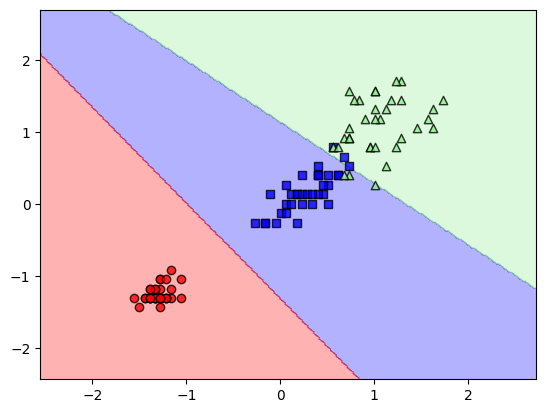

In [193]:
plot_decision_regions(X_train_std, y_train, LR)

In [196]:
weights, params = [], []
for c in np.arange(-4,4):
    print(f"C= {10.**c}")
    LR = LogisticRegression(C=10.**c, random_state=1,multi_class='ovr')
    LR.fit(X_train_std, y_train)
    weights.append(LR.coef_[1])
    params.append(10.**c)
weights = np.array(weights)



C= 0.0001
C= 0.001
C= 0.01
C= 0.1
C= 1.0
C= 10.0
C= 100.0
C= 1000.0


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\AppD

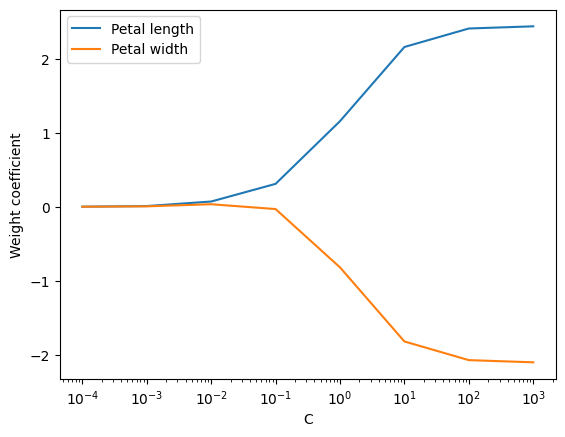

In [199]:
plt.plot(params,weights[:,0], label='Petal length')
plt.plot(params,weights[:,1], label='Petal width')
plt.xlabel('C')
plt.ylabel('Weight coefficient')
plt.xscale('log')
plt.legend()
plt.show()